# Pass@k overview and progression

Focus: show learning curves across steps and highlight top-performing algorithms for each metric. The plots are designed to support claims about performance advantages and stability over training steps.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlepad"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()


DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / 'combined_wide.csv')
combined = combined.drop(columns=[c for c in ['Unnamed: 0'] if c in combined.columns])
combined['seed'] = combined['seed'].astype(str)
metrics = [c for c in combined.columns if c.startswith('pass@') or c == 'avg@32']


DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




In [2]:

# Aggregate across seeds
mean_df = combined.groupby(['Step', 'algorithm'], as_index=False)[metrics].mean()
std_df = combined.groupby(['Step', 'algorithm'], as_index=False)[metrics].std()
final_step = int(mean_df['Step'].max())
final_df = mean_df[mean_df['Step'] == final_step].copy()


def top_algos(metric, n=5):
    return (
        final_df.sort_values(metric, ascending=False)['algorithm']
        .head(n)
        .tolist()
    )


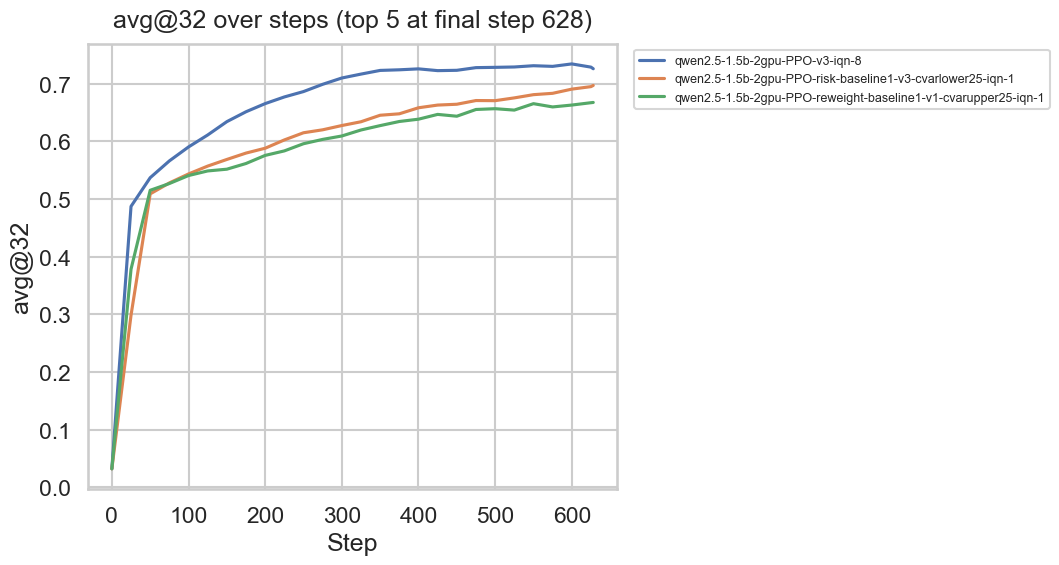

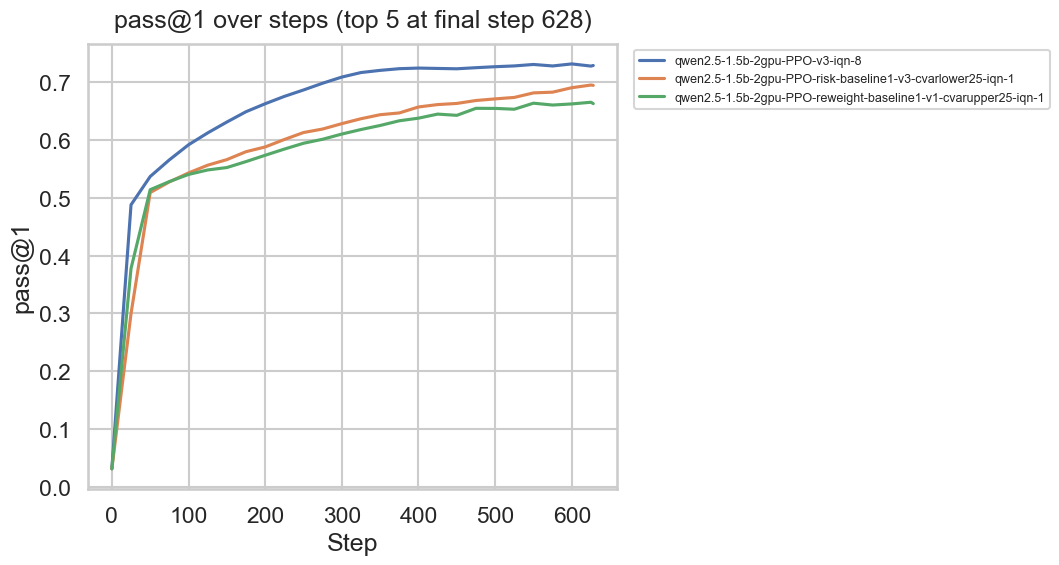

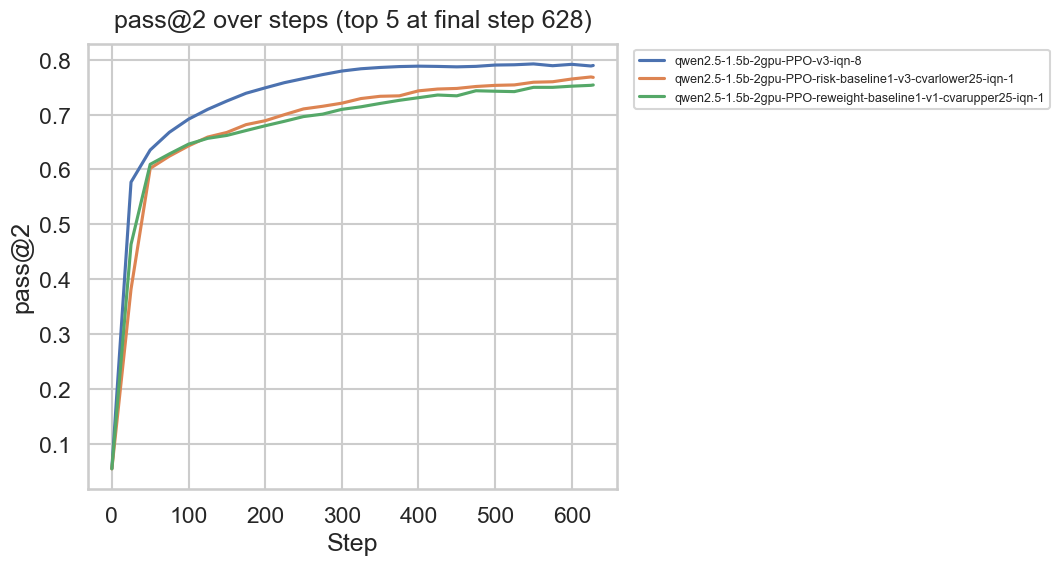

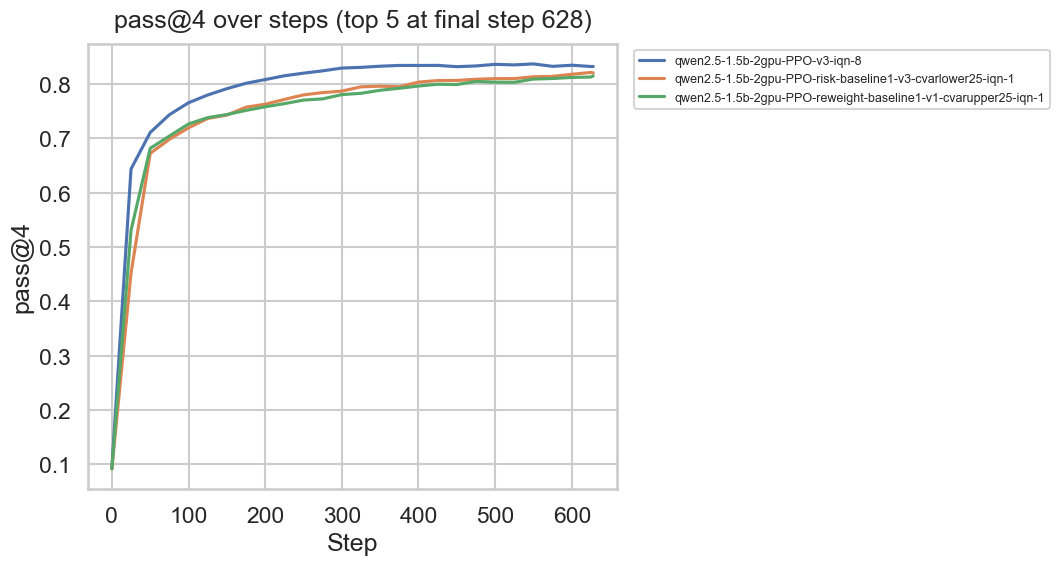

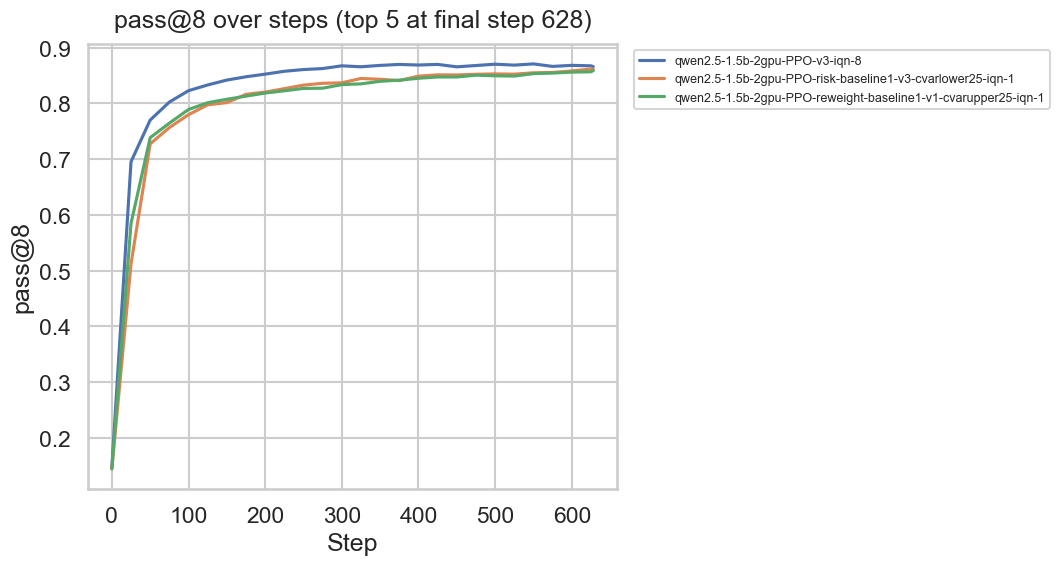

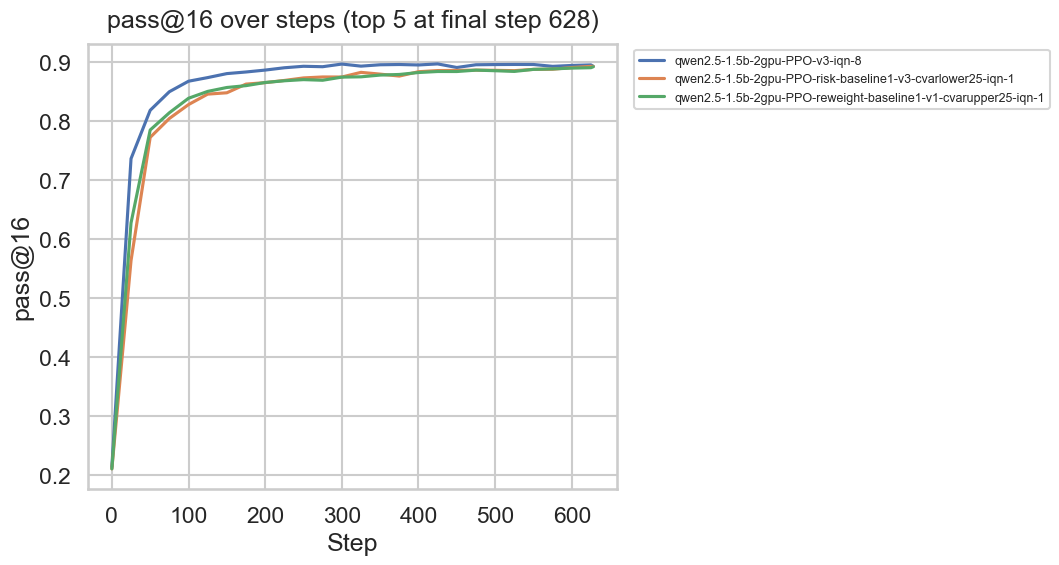

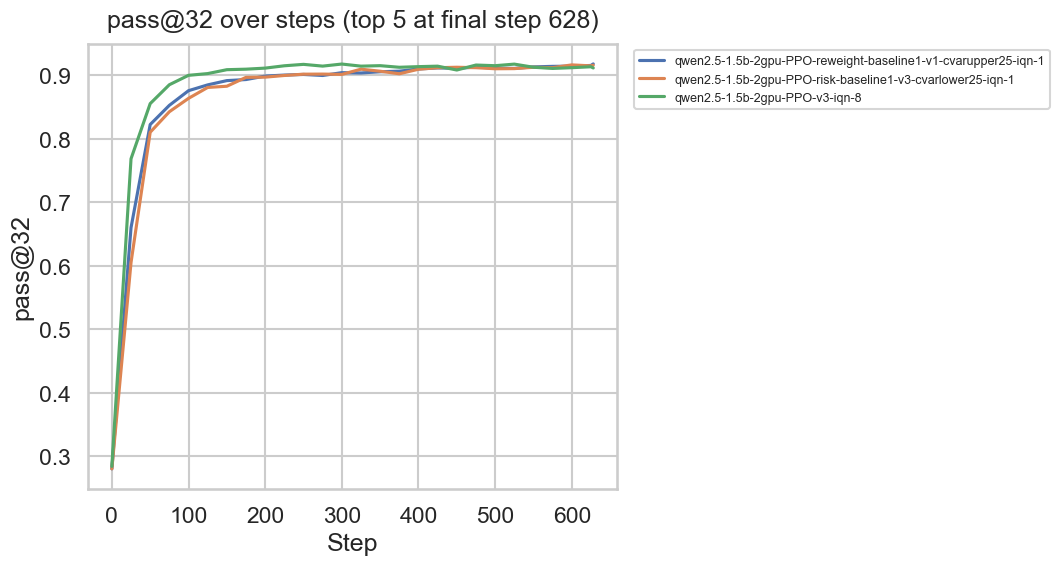

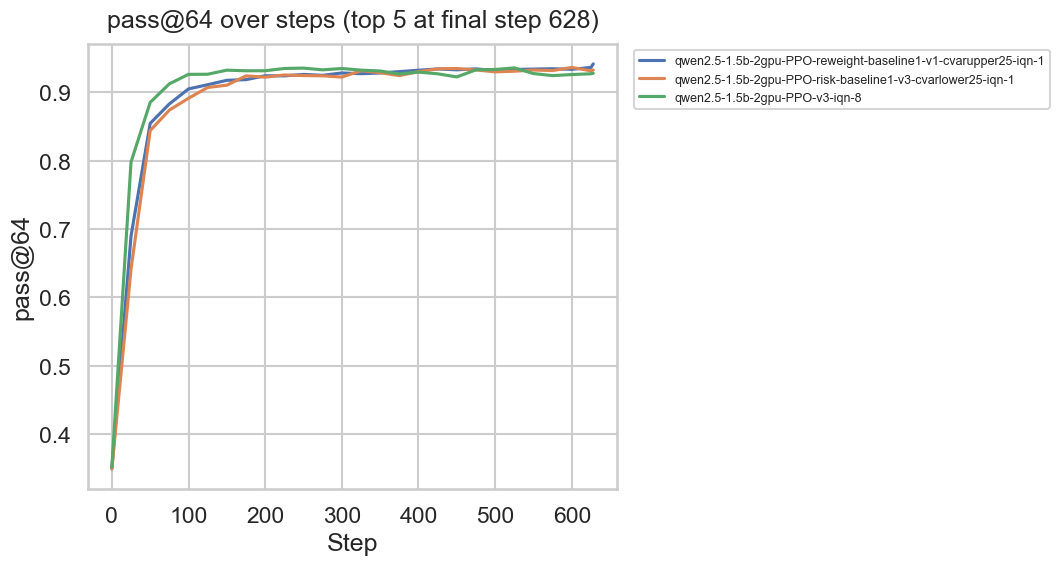

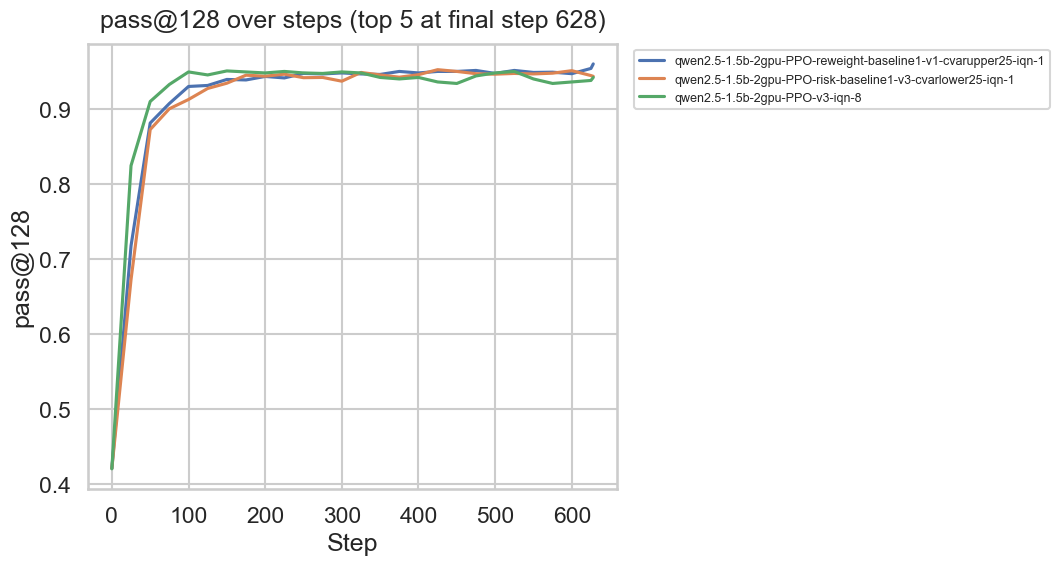

In [3]:

# Plot set A: metric curves for top algorithms
for metric in metrics:
    top = top_algos(metric, n=5)
    plt.figure()
    for algo in top:
        sub = mean_df[mean_df['algorithm'] == algo]
        plt.plot(sub['Step'], sub[metric], label=algo)
    plt.title(f"{metric} over steps (top 5 at final step {final_step})")
    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()
    plt.close()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


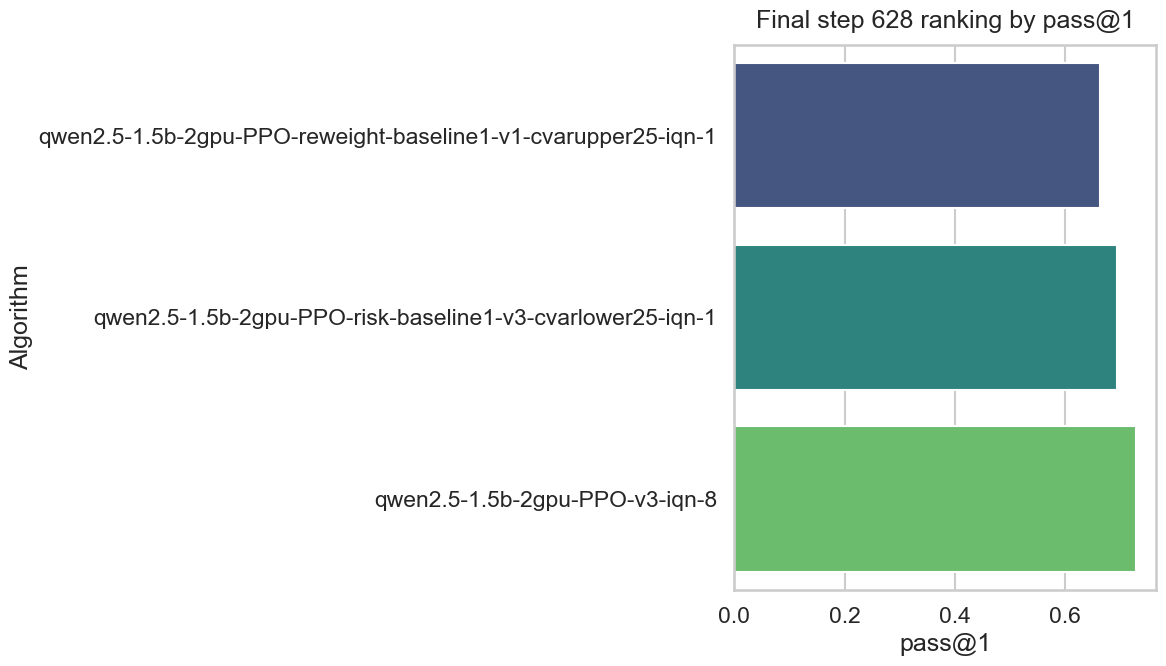

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


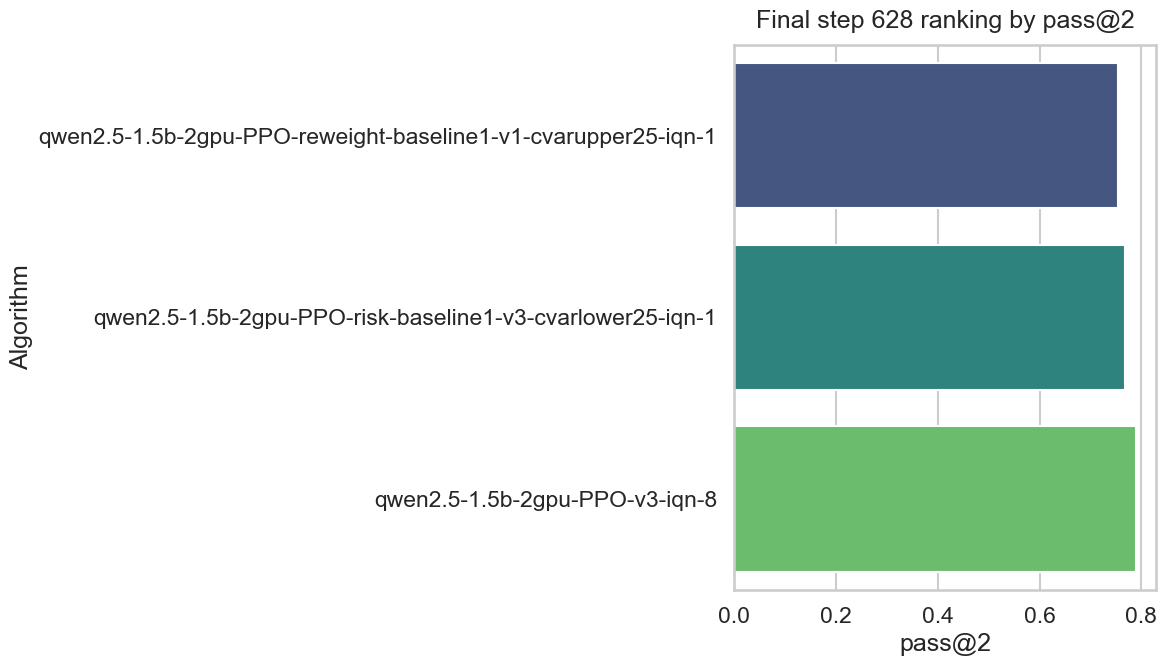

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


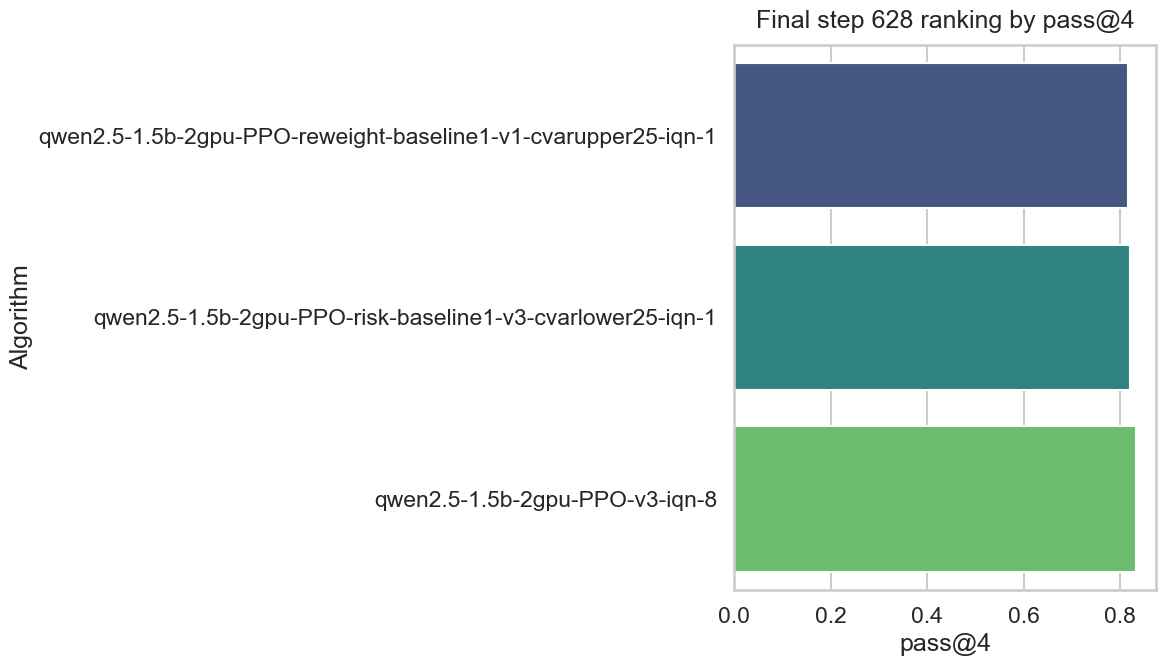

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


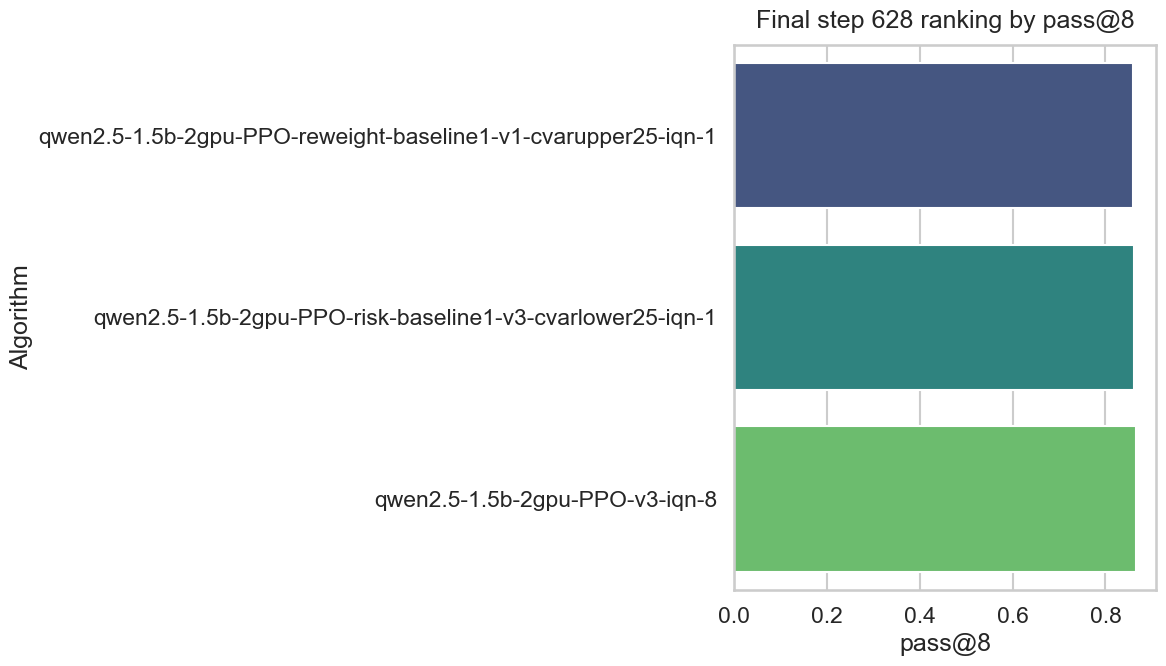

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


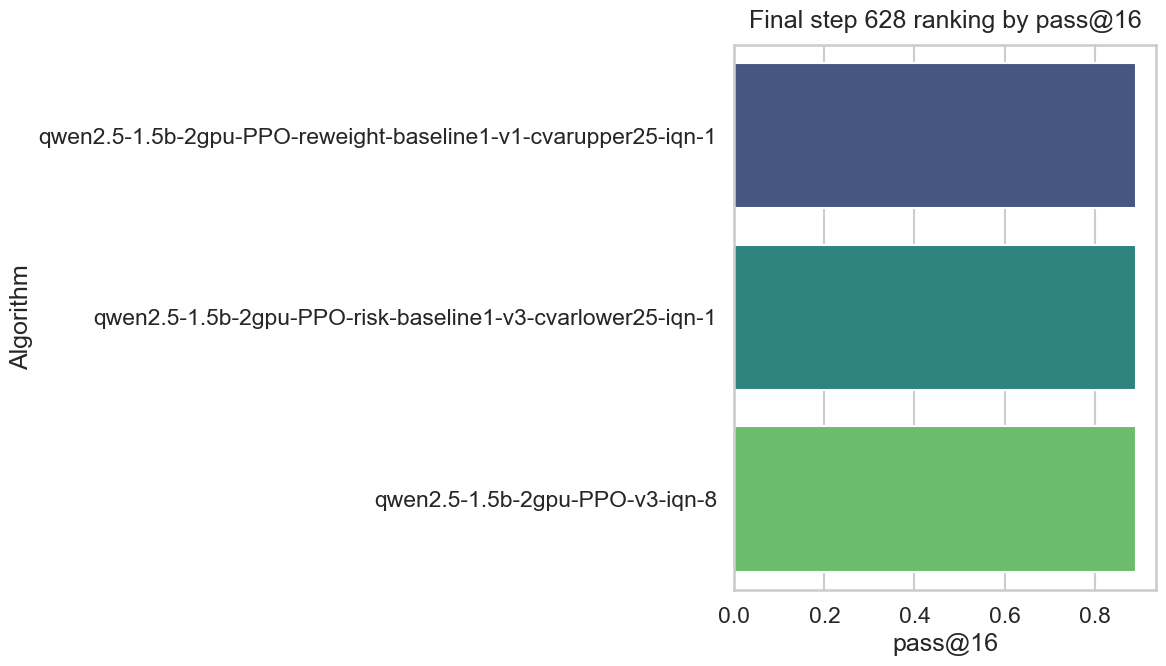

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


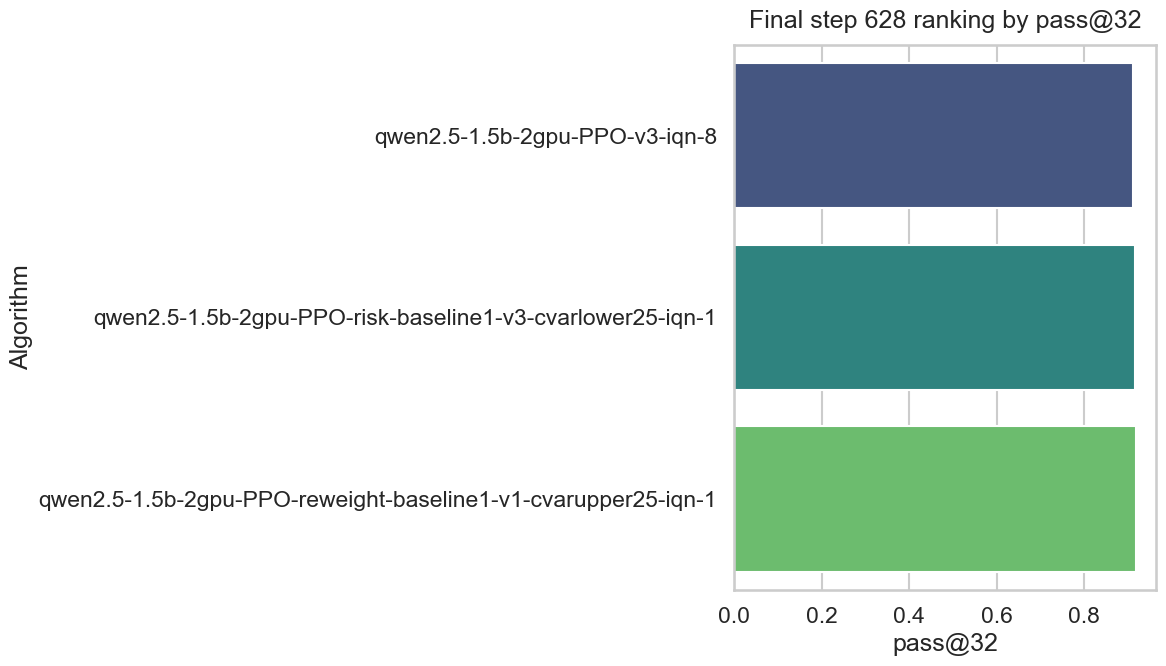

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


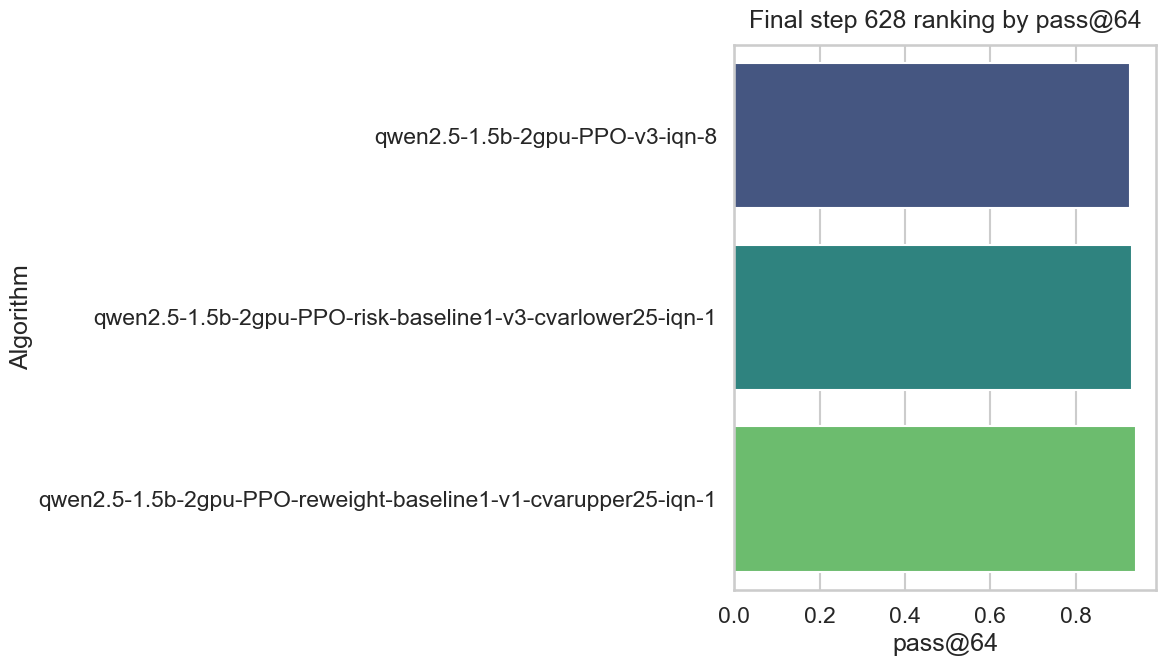

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94707/3171999762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')


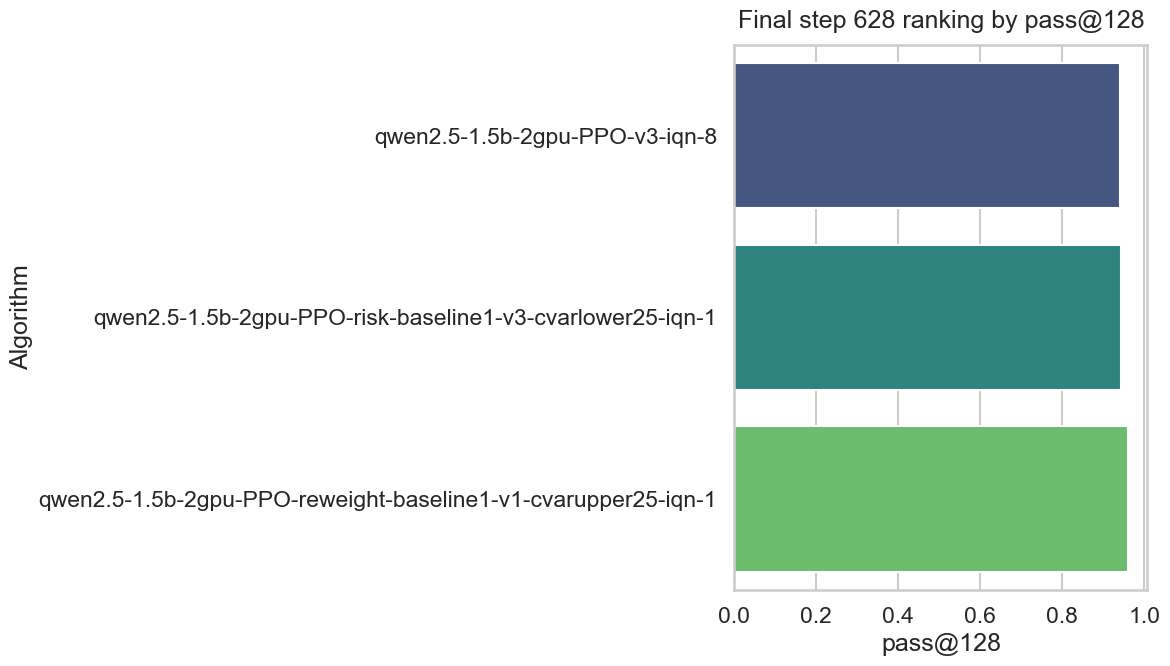

In [4]:

# Plot set B: final-step ranking for each pass@k
passk_metrics = [m for m in metrics if m.startswith('pass@')]
for metric in passk_metrics:
    order = final_df.sort_values(metric, ascending=True)
    plt.figure(figsize=(12, 7))
    sns.barplot(data=order, x=metric, y='algorithm', palette='viridis')
    plt.title(f"Final step {final_step} ranking by {metric}")
    plt.xlabel(metric)
    plt.ylabel("Algorithm")
    plt.tight_layout()
    plt.show()
    plt.close()


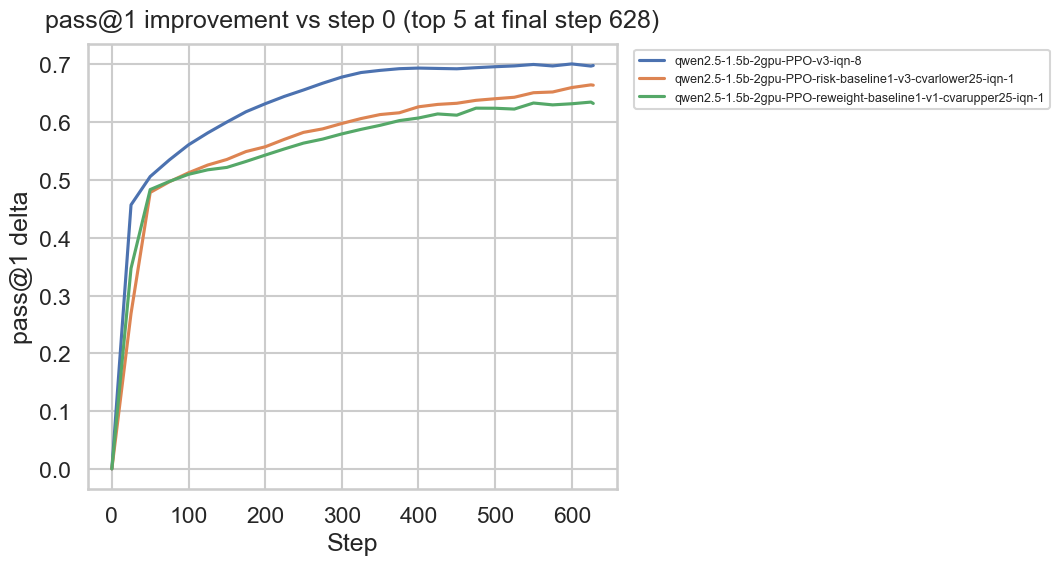

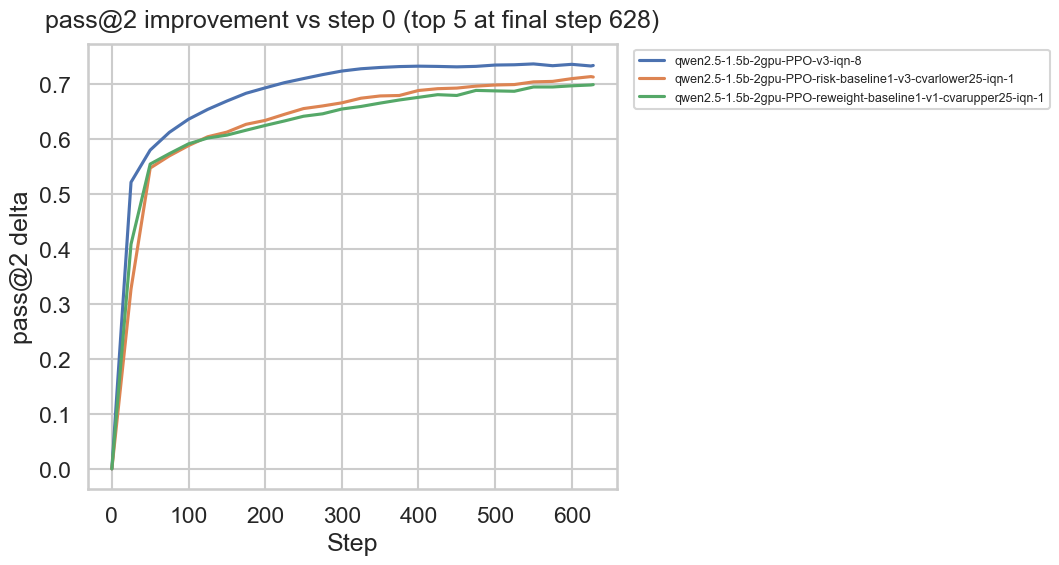

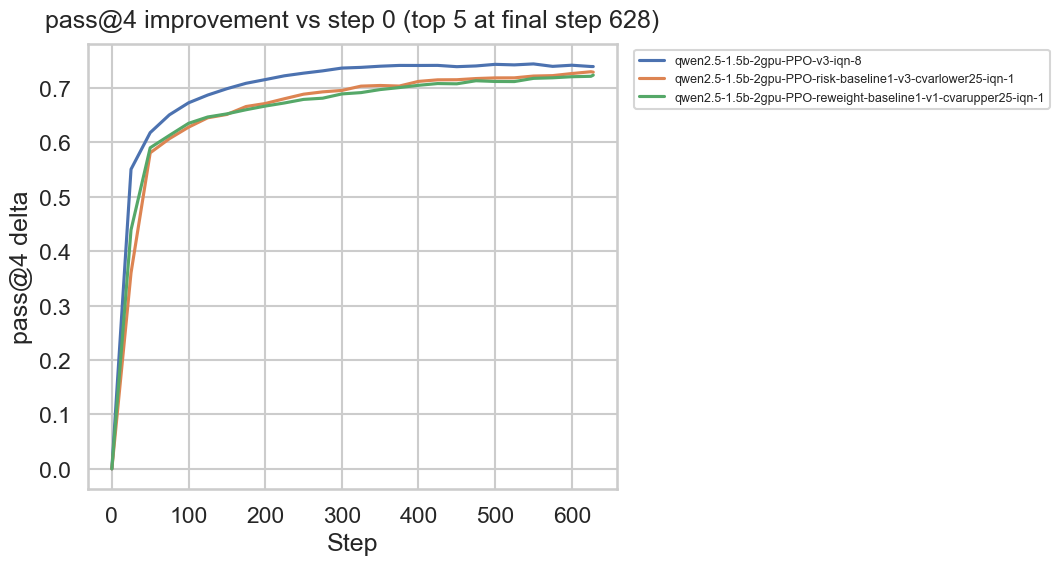

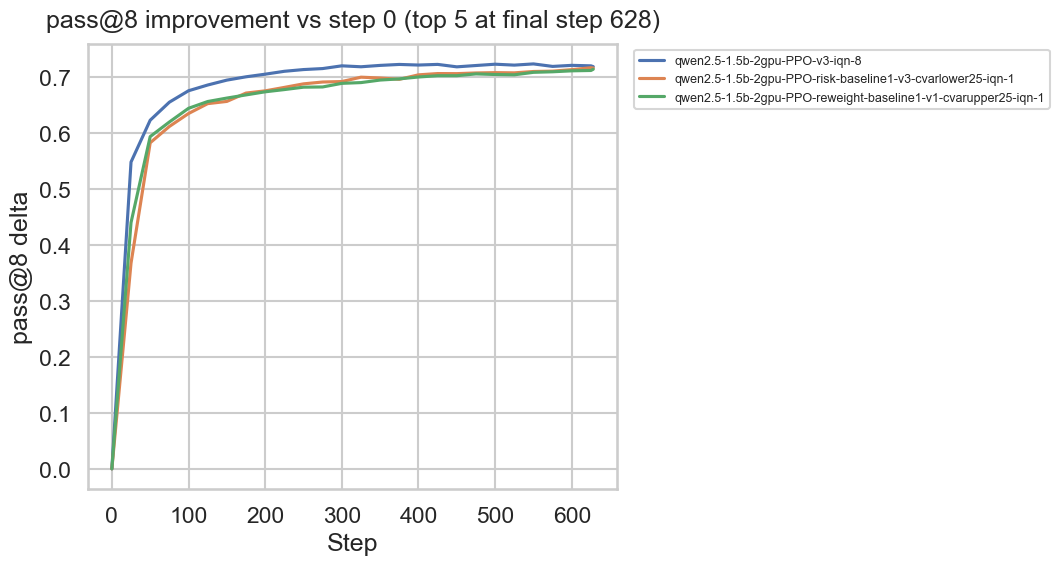

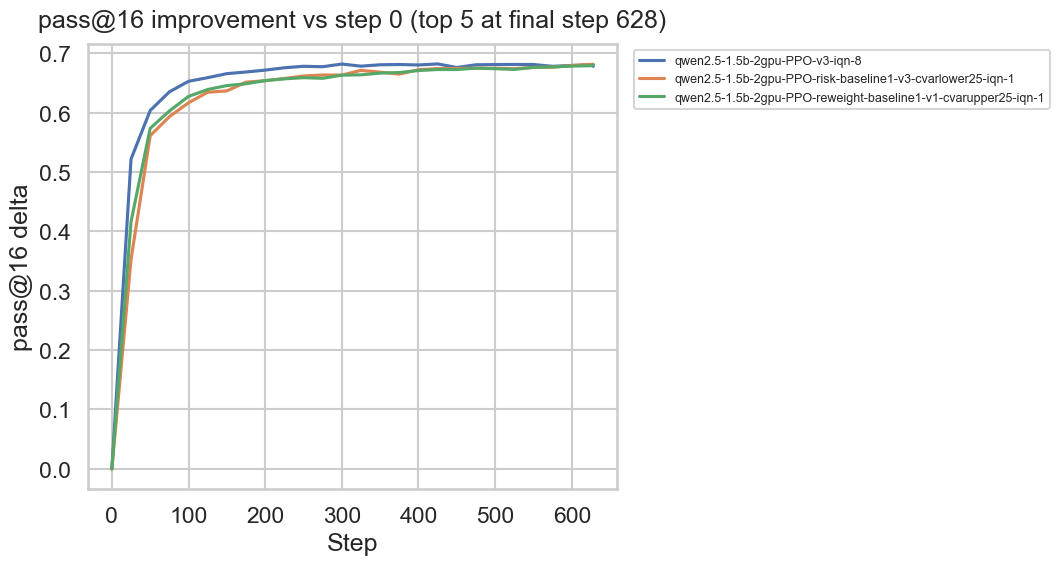

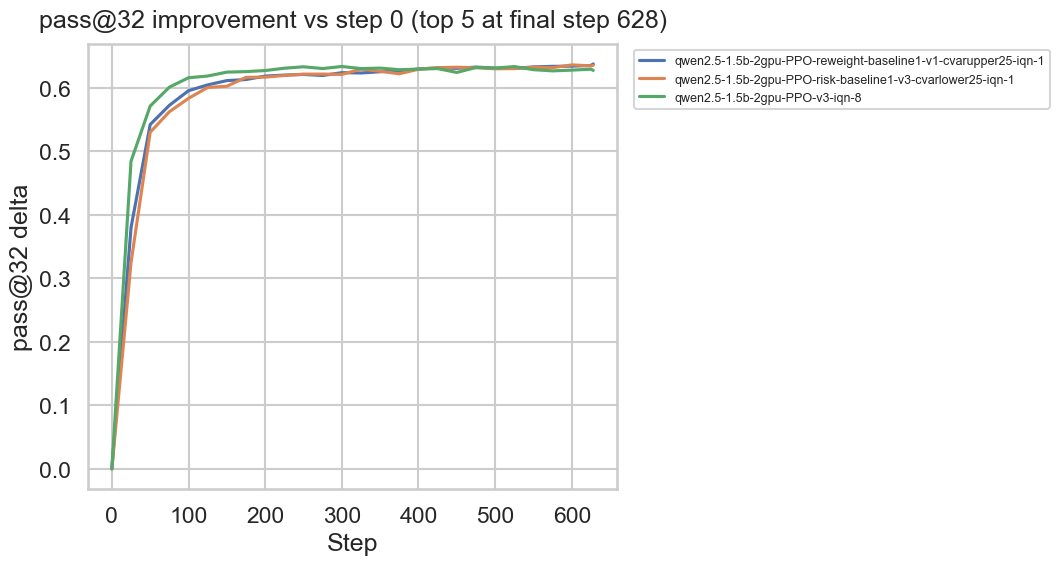

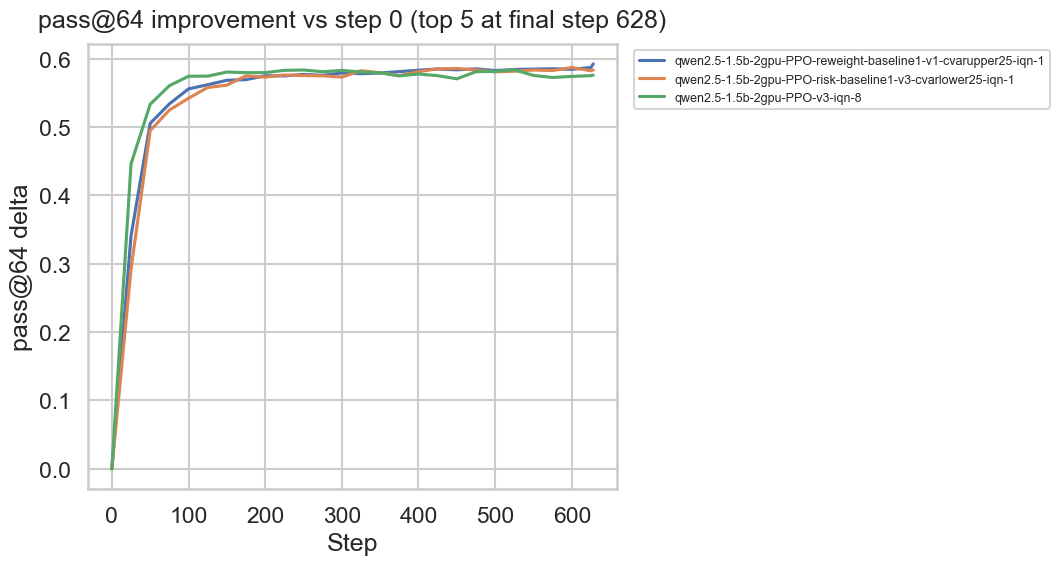

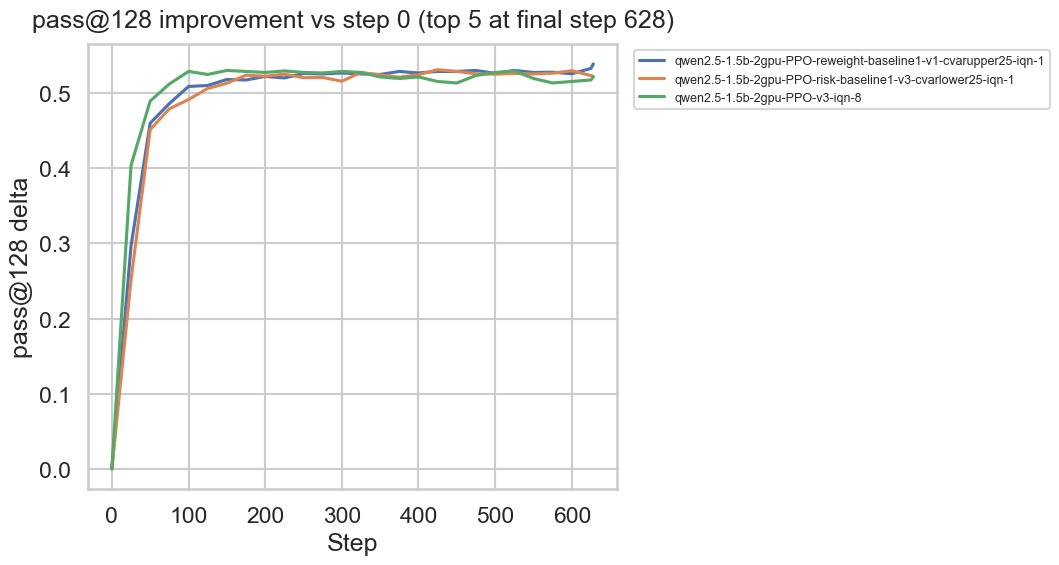

In [5]:

# Plot set C: improvement vs step 0 for top algorithms
base = mean_df[mean_df['Step'] == 0][['algorithm'] + metrics]
base = base.rename(columns={m: f"{m}_base" for m in metrics})
imp = mean_df.merge(base, on='algorithm', how='left')
for m in metrics:
    imp[f"{m}_delta"] = imp[m] - imp[f"{m}_base"]

for metric in passk_metrics:
    top = top_algos(metric, n=5)
    plt.figure()
    for algo in top:
        sub = imp[imp['algorithm'] == algo]
        plt.plot(sub['Step'], sub[f"{metric}_delta"], label=algo)
    plt.title(f"{metric} improvement vs step 0 (top 5 at final step {final_step})")
    plt.xlabel("Step")
    plt.ylabel(f"{metric} delta")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()
    plt.close()
